In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/ml_checkpoints/model.pth"

In [ ]:
PREPROCESSED_DATASET_PATH = "/content/drive/MyDrive/urpc2020_preprocessed"

In [ ]:
# Removed opencv-contrib-python from here to manage installation order explicitly.

In [ ]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install ultralytics kagglehub timm
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (79.2 MB)


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from ultralytics import YOLO
import kagglehub

In [ ]:
path = kagglehub.dataset_download("lywang777/urpc2020")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'urpc2020' dataset.
Dataset Path: /kaggle/input/urpc2020


In [ ]:
# import yaml
# import os

# yaml_path = os.path.join(path, "URPC2020/data.yaml")

# with open(yaml_path) as f:
#     data = yaml.safe_load(f)

# # Correcting the paths in the data dictionary
# base_dataset_path = os.path.join(path, "URPC2020")
# data['path'] = base_dataset_path
# data['train'] = os.path.join(base_dataset_path, "train/images")
# data['val'] = os.path.join(base_dataset_path, "valid/images")
# data['test'] = os.path.join(base_dataset_path, "test/images")

# with open("data.yaml", "w") as f:
#     yaml.dump(data, f)

In [ ]:
import yaml
import os

yaml_path = os.path.join(path, "URPC2020/data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

base_dataset_path = PREPROCESSED_DATASET_PATH
data['path'] = base_dataset_path
data['train'] = os.path.join(base_dataset_path, "train/images")
data['val'] = os.path.join(base_dataset_path, "valid/images")
data['test'] = os.path.join(base_dataset_path, "test/images")

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

print(f"data.yaml updated to point to preprocessed data at: {base_dataset_path}")

data.yaml updated to point to preprocessed data at: /content/drive/MyDrive/urpc2020_preprocessed


In [ ]:
def preprocess_image(img):

    wb = cv2.xphoto.createSimpleWB()
    img = wb.balanceWhite(img)


    img = cv2.GaussianBlur(img, (5,5), 0)


    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    img = cv2.merge((cl,a,b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    return img

In [ ]:
import os
import cv2
from tqdm.notebook import tqdm

base_path = os.path.join(path, "URPC2020")

def process_folder(folder):
    print(f"Processing images in: {folder}")
    for img_name in tqdm(os.listdir(folder), desc=f"Processing {os.path.basename(folder)}"):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        processed = preprocess_image(img)
        cv2.imwrite(img_path, processed)

for split in ["train", "valid", "test"]:
    process_folder(os.path.join(base_path, split, "images"))

print("Preprocessing Done ")

In [ ]:
import os
import cv2
from tqdm.notebook import tqdm


original_base_path = os.path.join(path, "URPC2020")

output_base_path = PREPROCESSED_DATASET_PATH

def process_folder_and_save(input_folder, output_folder):
    print(f"Processing images from: {input_folder} and saving to: {output_folder}")
    os.makedirs(output_folder, exist_ok=True)

    for img_name in tqdm(os.listdir(input_folder), desc=f"Processing {os.path.basename(input_folder)}"):
        img_path = os.path.join(input_folder, img_name)
        output_img_path = os.path.join(output_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:

            continue

        processed = preprocess_image(img)
        cv2.imwrite(output_img_path, processed)

for split in ["train", "valid", "test"]:
    input_folder = os.path.join(original_base_path, split, "images")
    output_folder = os.path.join(output_base_path, split, "images")
    process_folder_and_save(input_folder, output_folder)

print("Preprocessing and Saving to Google Drive Done ✅")

Processing images from: /root/.cache/kagglehub/datasets/lywang777/urpc2020/versions/1/URPC2020/train/images and saving to: /content/drive/MyDrive/urpc2020_preprocessed/train/images


Processing images:   0%|          | 0/5543 [00:00<?, ?it/s]

Processing images from: /root/.cache/kagglehub/datasets/lywang777/urpc2020/versions/1/URPC2020/valid/images and saving to: /content/drive/MyDrive/urpc2020_preprocessed/valid/images


Processing images:   0%|          | 0/1200 [00:00<?, ?it/s]

Processing images from: /root/.cache/kagglehub/datasets/lywang777/urpc2020/versions/1/URPC2020/test/images and saving to: /content/drive/MyDrive/urpc2020_preprocessed/test/images


Processing images:   0%|          | 0/800 [00:00<?, ?it/s]

Preprocessing and Saving to Google Drive Done ✅


In [ ]:
import shutil

original_base_path = os.path.join(path, "URPC2020")

output_base_path = PREPROCESSED_DATASET_PATH

print("Copying label files to Google Drive...")

for split in ["train", "valid", "test"]:
    original_labels_folder = os.path.join(original_base_path, split, "labels")
    output_labels_folder = os.path.join(output_base_path, split, "labels")

    os.makedirs(output_labels_folder, exist_ok=True)


    for label_file in os.listdir(original_labels_folder):
        shutil.copy(os.path.join(original_labels_folder, label_file), output_labels_folder)
    print(f"Copied labels for {split} split to: {output_labels_folder}")

print("Label copying complete! Please re-run cell ID 325b93e2 and then your training cell.")

Copying label files to Google Drive...
Copied labels for train split to: /content/drive/MyDrive/urpc2020_preprocessed/train/labels
Copied labels for valid split to: /content/drive/MyDrive/urpc2020_preprocessed/valid/labels
Copied labels for test split to: /content/drive/MyDrive/urpc2020_preprocessed/test/labels
Label copying complete! Please re-run cell ID 325b93e2 and then your training cell.


In [ ]:
import shutil
import os

# Define local path
LOCAL_DATASET_PATH = "/content/dataset"

if os.path.exists(PREPROCESSED_DATASET_PATH):
    print(f" Copying dataset from Drive to local storage: {LOCAL_DATASET_PATH}...")
    if os.path.exists(LOCAL_DATASET_PATH):
        shutil.rmtree(LOCAL_DATASET_PATH)

    shutil.copytree(PREPROCESSED_DATASET_PATH, LOCAL_DATASET_PATH)
    print(" Copy complete! Local storage is ready for fast training.")
else:
    print(f" Source path not found in Drive: {PREPROCESSED_DATASET_PATH}")

 Copying dataset from Drive to local storage: /content/dataset...
 Copy complete! Local storage is ready for fast training.


In [ ]:
import yaml


with open("data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

local_base = "/content/dataset"
data_config['path'] = local_base
data_config['train'] = os.path.join(local_base, "train/images")
data_config['val'] = os.path.join(local_base, "valid/images")
data_config['test'] = os.path.join(local_base, "test/images")

with open("data.yaml", "w") as f:
    yaml.dump(data_config, f)

print(" data.yaml updated to use local Colab storage.")

 data.yaml updated to use local Colab storage.


In [ ]:
class ECAModule(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECAModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y

In [ ]:
import timm
import torch.nn as nn

class MobileNetV3_ECA(nn.Module):
    def __init__(self, num_classes=2, eca_k_size=3, dropout=0.3):
        super().__init__()

        self.backbone = timm.create_model(
            'mobilenetv3_small_100',
            pretrained=True,
            features_only=True
        )
        self.eca = ECAModule(576, k_size=eca_k_size)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(576, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        x = features[-1]

        x = self.eca(x)

        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

In [ ]:
# model = YOLO("yolov8n.pt")

In [ ]:
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

model = YOLO("yolov8n.pt")


Mounted at /content/drive


In [ ]:
import os
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


project_path = "/content/drive/MyDrive/yolo_training"
exp_name = "exp1"
checkpoint_path = os.path.join(project_path, exp_name, "weights/last.pt")

if os.path.exists(checkpoint_path):
    print(f" Resuming from last checkpoint: {checkpoint_path}")
    model = YOLO(checkpoint_path)
    resume_training = True
else:
    print(" Starting fresh training with yolov8n.pt")
    model = YOLO("yolov8n.pt")
    resume_training = False

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=320,
    batch=32,
    workers=4,
    device=device,
    project=project_path,
    name=exp_name,
    save=True,
    save_period=1,
    resume=resume_training
)

Using device: cpu
🚀 Starting fresh training with yolov8n.pt
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp17, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bccf59e0530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
#upload model file code

In [ ]:
import os
from ultralytics import YOLO


uploaded_model_filename = list(uploaded.keys())[0] if uploaded else None

if uploaded_model_filename and os.path.exists(uploaded_model_filename):
    print(f"Loading model from: {uploaded_model_filename}")
    model = YOLO(uploaded_model_filename)
    print("Model loaded successfully!")
else:
    print("No model file uploaded or file not found. Please upload your .pt file first.")

Loading model from: last.pt
Model loaded successfully!


In [ ]:

if 'model' in locals() and model is not None:
    print("Running model validation...")
    metrics = model.val()
    print(metrics)
else:
    print("Model not loaded. Please ensure you've uploaded and loaded your model correctly.")

Running model validation...
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 236.0±60.4 MB/s, size: 1888.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 1200 images, 47 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 209.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 2.1s/it 2:41
                   all       1200       9390      0.628      0.409      0.445      0.215
           holothurian        255        461      0.513      0.332      0.325      0.157
               echinus        816       4233      0.695      0.611      0.663      0.306
               scallop        315       3196        0.7      0.224      0.318      0.156
              starfish        558       1500      0.604      0.469      0.475      0.239
Speed: 0.4ms pr

Running predictions on sample test images...

image 1/1 /content/dataset/test/images/000683.jpg: 192x320 4 echinuss, 1 starfish, 64.3ms
Speed: 5.0ms preprocess, 64.3ms inference, 29.4ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000071.jpg: 192x320 1 echinus, 47.0ms
Speed: 1.2ms preprocess, 47.0ms inference, 12.5ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000725.jpg: 192x320 5 echinuss, 45.3ms
Speed: 1.4ms preprocess, 45.3ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000667.jpg: 192x320 1 echinus, 2 starfishs, 46.6ms
Speed: 1.4ms preprocess, 46.6ms inference, 0.8ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000349.jpg: 192x320 2 scallops, 1 starfish, 47.8ms
Speed: 1.4ms preprocess, 47.8ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/image

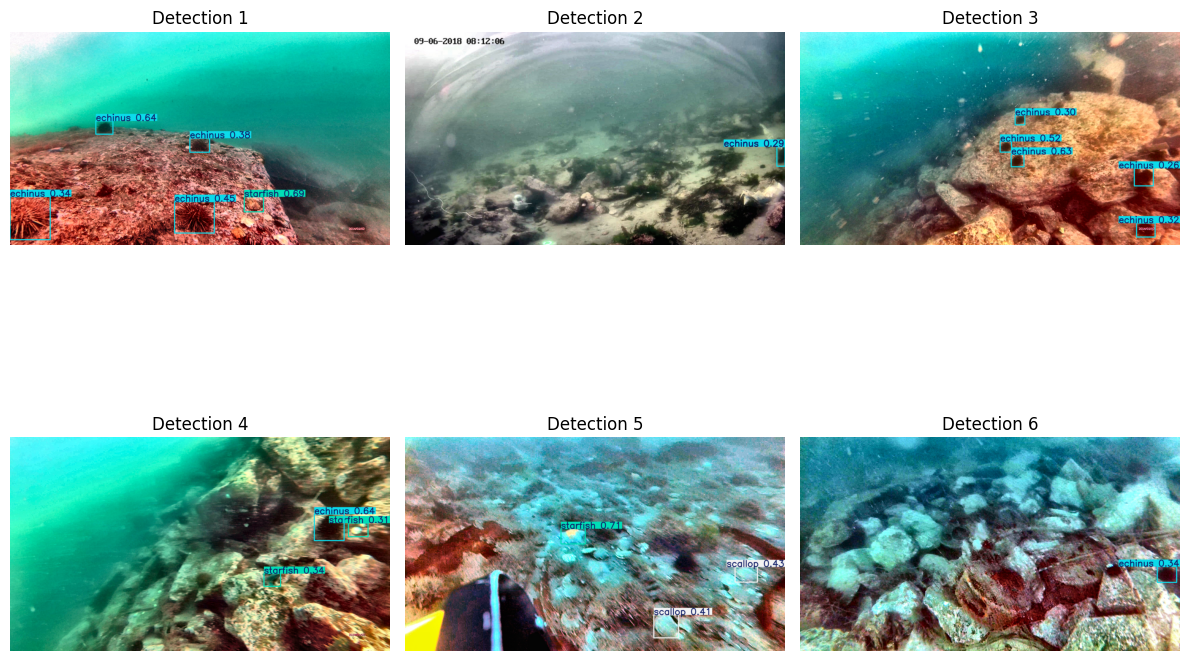

In [ ]:
import random
import cv2
import os
import matplotlib.pyplot as plt

local_base = "/content/dataset"

if 'model' in locals() and model is not None:
    print("Running predictions on sample test images...")
    test_path = os.path.join(local_base, "test/images")

    if not os.path.exists(test_path):
        print(f"Error: Path not found: {test_path}")
    else:

        image_list = random.sample(os.listdir(test_path), min(6, len(os.listdir(test_path))))

        plt.figure(figsize=(12,10))

        for i, img_name in enumerate(image_list):
            img_path = os.path.join(test_path, img_name)

            results = model.predict(
                source=img_path,
                conf=0.25,
                save=False
            )


            if results and hasattr(results[0], 'plot'):
                plotted_img = results[0].plot()

                plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

                plt.subplot(2, 3, i+1)
                plt.imshow(plotted_img)
                plt.title(f"Detection {i+1}")
                plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("Model not loaded. Cannot run predictions.")

Running predictions on sample test images...

image 1/1 /content/dataset/test/images/000451.jpg: 192x320 (no detections), 72.5ms
Speed: 1.8ms preprocess, 72.5ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000569.jpg: 192x320 (no detections), 71.2ms
Speed: 2.2ms preprocess, 71.2ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000412.jpg: 192x320 2 scallops, 1 starfish, 71.4ms
Speed: 1.9ms preprocess, 71.4ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/images/000074.jpg: 256x320 (no detections), 105.5ms
Speed: 2.3ms preprocess, 105.5ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 /content/dataset/test/images/000598.jpg: 192x320 1 echinus, 3 starfishs, 80.3ms
Speed: 1.6ms preprocess, 80.3ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)

image 1/1 /content/dataset/test/i

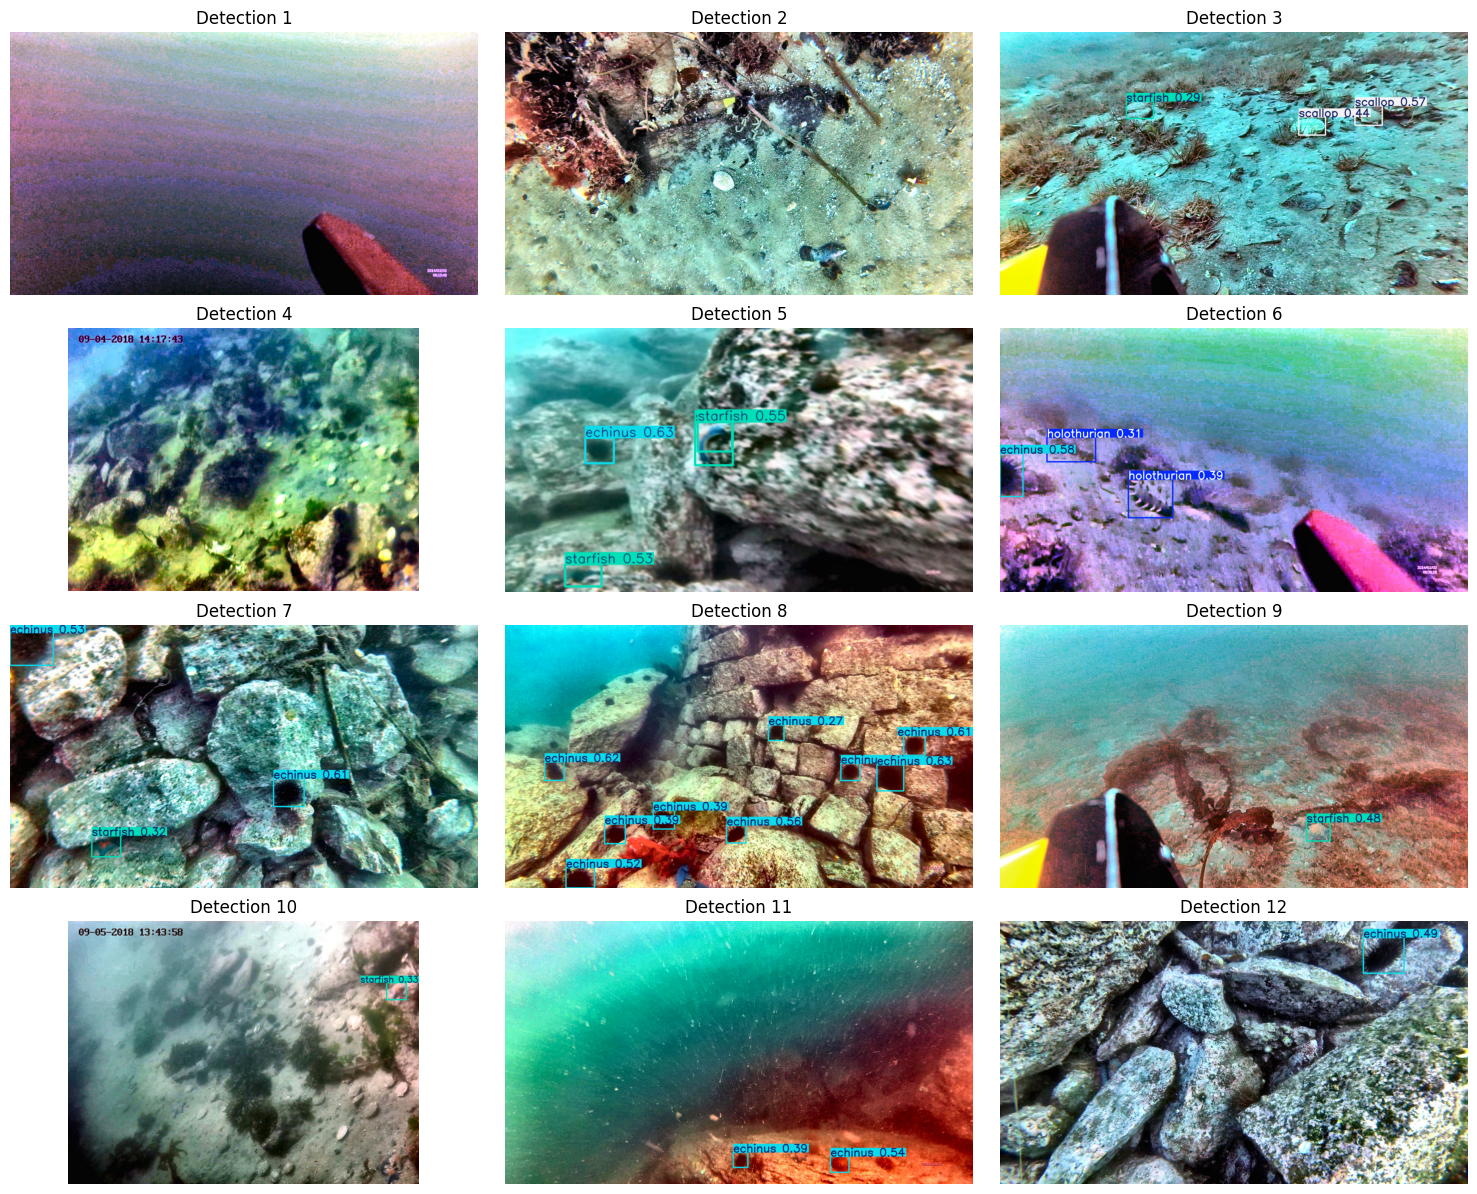

In [ ]:
import random
import cv2
import os
import matplotlib.pyplot as plt

local_base = "/content/dataset"

if 'model' in locals() and model is not None:
    print("Running predictions on sample test images...")
    test_path = os.path.join(local_base, "test/images")

    if not os.path.exists(test_path):
        print(f"Error: Path not found: {test_path}")
    else:

        image_list = random.sample(os.listdir(test_path), min(6, len(os.listdir(test_path))))

        plt.figure(figsize=(12,10))

        for i, img_name in enumerate(image_list):
            img_path = os.path.join(test_path, img_name)

            results = model.predict(
                source=img_path,
                conf=0.25,
                save=False
            )


            if results and hasattr(results[0], 'plot'):
                plotted_img = results[0].plot()

                plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

                plt.subplot(2, 3, i+1)
                plt.imshow(plotted_img)
                plt.title(f"Detection {i+1}")
                plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("Model not loaded. Cannot run predictions.")

 Loading model: /content/drive/MyDrive/yolo_training/exp17/weights/last.pt
Please upload your test images (.jpg, .png, etc.):


Saving 000774.jpg to 000774 (1).jpg
Saving 000797.jpg to 000797.jpg
Saving 005540.jpg to 005540 (1).jpg

Processing 3 images...


image 1/1 /content/000774 (1).jpg: 192x320 4 echinuss, 1 starfish, 74.5ms
Speed: 2.0ms preprocess, 74.5ms inference, 1.3ms postprocess per image at shape (1, 3, 192, 320)


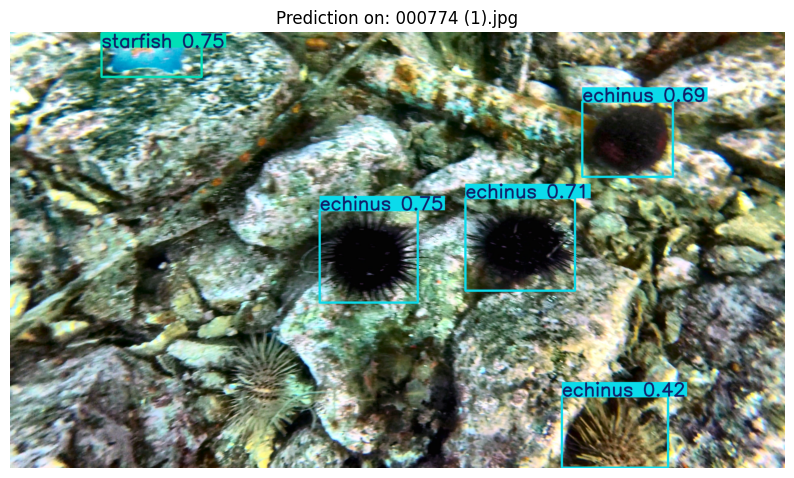


image 1/1 /content/000797.jpg: 192x320 8 echinuss, 4 starfishs, 87.1ms
Speed: 6.3ms preprocess, 87.1ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)


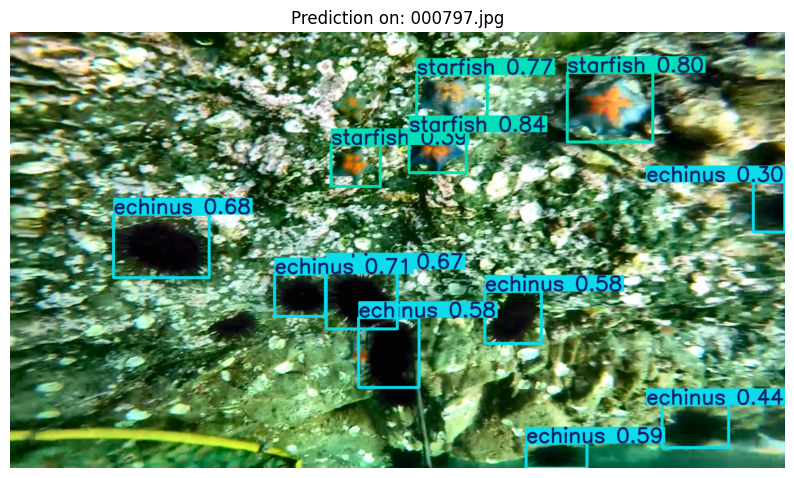


image 1/1 /content/005540 (1).jpg: 192x320 13 echinuss, 14 starfishs, 70.3ms
Speed: 1.8ms preprocess, 70.3ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)


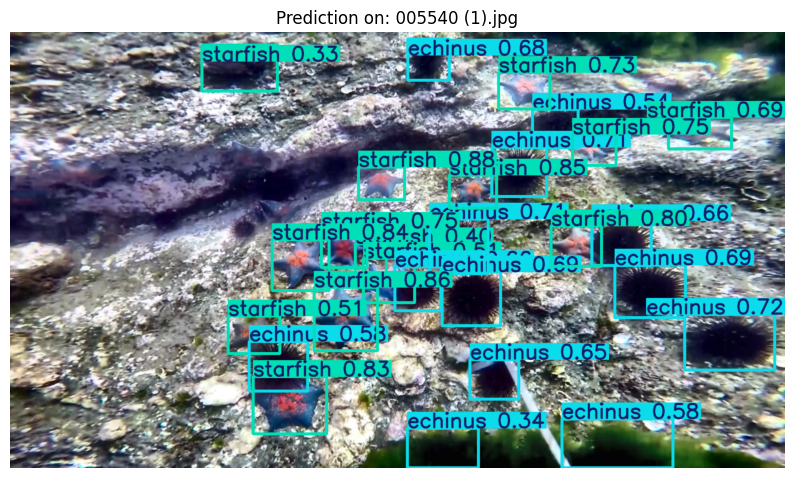

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


EXP17_MODEL_PATH = "/content/drive/MyDrive/yolo_training/exp17/weights/last.pt"

if not os.path.exists(EXP17_MODEL_PATH):
    print(f" Model not found at: {EXP17_MODEL_PATH}")
else:

    print(f" Loading model: {EXP17_MODEL_PATH}")
    model_exp17 = YOLO(EXP17_MODEL_PATH)


    print("Please upload your test images (.jpg, .png, etc.):")
    uploaded = files.upload()

    if uploaded:
        print(f"\nProcessing {len(uploaded)} images...\n")
        for filename in uploaded.keys():
            results = model_exp17.predict(source=filename, conf=0.25, save=False)


            plotted_img = results[0].plot()
            plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(plotted_img_rgb)
            plt.title(f"Prediction on: {filename}")
            plt.axis('off')
            plt.show()
    else:
        print("No files uploaded.")

In [ ]:
# import os
# import kagglehub

# # Re-define path and base_path within this cell to ensure they are available
# path = kagglehub.dataset_download("lywang777/urpc2020")
# base_path = os.path.join(path, "URPC2020")

# # Get all image paths from the test directory
# test_images_dir = os.path.join(base_path, "test/images")
# all_image_names = os.listdir(test_images_dir)

# # Select the first 300 image paths
# selected_image_paths = [os.path.join(test_images_dir, img_name) for img_name in all_image_names[:300]]

# results = model.predict(
#     source=selected_image_paths,
#     save=True,
#     conf=0.25
# )

In [ ]:
# import os
# import random
# import cv2
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# # Load trained model
# model = YOLO("runs/detect/train/weights/last.pt")

# # Path to test images
# test_path = os.path.join(base_path, "test/images")

# # Select 6 random images
# image_list = random.sample(os.listdir(test_path), 6)

# plt.figure(figsize=(12,10))

# for i, img_name in enumerate(image_list):
#     img_path = os.path.join(test_path, img_name)

#     # Run prediction
#     results = model.predict(
#         source=img_path,
#         conf=0.25,
#         save=False   # IMPORTANT: don't save, just display
#     )

#     # Get plotted image with bounding boxes
#     plotted_img = results[0].plot()

#     # Convert BGR → RGB
#     plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

#     # Display
#     plt.subplot(2, 2, i+1)
#     plt.imshow(plotted_img)
#     plt.title(f"Detection {i+1}")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()